# Dollar Bar Dataset Builder

Downloads Binance Vision aggTrade ZIPs, converts them to dollar bars, engineers
microstructure features, and writes a Parquet file ready for ML prototyping.

**No database required.** ZIPs are cached locally in `data/zip_cache/` so
re-running the notebook is fast after the first download.

---
### Output columns
| Column | Description |
|---|---|
| `open/high/low/close` | OHLC prices |
| `volume`, `dollar_volume` | Total and dollar volume |
| `buy_volume`, `sell_volume` | Tick-rule classified volumes |
| `trade_count` | Trades per bar |
| `ofi` | Order Flow Imbalance ∈ [−1, 1] |
| `kyle_lambda` | Price impact per unit signed flow |
| `realized_vol` | √Σ(log return)² over bar trades |
| `duration_s` | Seconds to fill bar |
| `log_return` | log(close / prev_close) |
| `vpin_10`, `vpin_50` | Rolling VPIN over 10 / 50 bars |
| `dollar_vol_z` | Z-score of dollar_volume (rolling 50-bar window) |
| `ofi_lag1`, `ofi_lag2` | Lagged OFI |
| `kyle_lag1` | Lagged Kyle λ |
| `vol_lag1` | Lagged realized volatility |
| `ret_1b`, `ret_5b` | Forward log returns (target variables) |

In [1]:
# ── 0. Imports ──────────────────────────────────────────────────────────────
import sys
from pathlib import Path

ROOT = Path("__file__").resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import math
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date, timedelta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.ingestion.historical import stream_trades, iter_dates, fetch_zip
from src.processing.bars import AccumulatorState, process_trade
from src.processing.threshold import calibrate

from src.features.bsadf import qadf

sns.set_theme(style="darkgrid")
print("Imports OK")

Imports OK


In [2]:
# ── 1. Parameters ────────────────────────────────────────────────────────────
SYMBOL              = "BTCUSDT"
TARGET_BARS_PER_DAY = 75
CALIB_DAYS          = 5       # days sampled to estimate the threshold
DOWNLOAD_WORKERS    = 8       # parallel download threads

END_DATE   = date.today() - timedelta(days=3)
START_DATE = END_DATE - timedelta(days=89)   # 90 days

CACHE_DIR = ROOT / "data" / "zip_cache"      # ZIPs saved here; delete to force re-download
OUT_PATH  = ROOT / "data" / "dollar_bars.parquet"

print(f"Symbol : {SYMBOL}")
print(f"Range  : {START_DATE} → {END_DATE}  ({(END_DATE - START_DATE).days + 1} days)")
print(f"Cache  : {CACHE_DIR}")
print(f"Output : {OUT_PATH}")

Symbol : BTCUSDT
Range  : 2026-01-27 → 2026-04-26  (90 days)
Cache  : C:\Users\Atlas\Documents\Proyectos\quant_binance\data\zip_cache
Output : C:\Users\Atlas\Documents\Proyectos\quant_binance\data\dollar_bars.parquet


In [3]:
# ── 2. Parallel download ─────────────────────────────────────────────────────
# Download all missing ZIPs in parallel before doing any processing.
# Already-cached files are skipped immediately (fetch_zip checks disk first).

all_dates = list(iter_dates(START_DATE, END_DATE))

missing = [
    day for day in all_dates
    if not (CACHE_DIR / f"{SYMBOL}-aggTrades-{day.isoformat()}.zip").exists()
]
print(f"{len(all_dates) - len(missing)} days already cached, {len(missing)} to download")

if missing:
    failed = []
    with ThreadPoolExecutor(max_workers=DOWNLOAD_WORKERS) as pool:
        futures = {pool.submit(fetch_zip, SYMBOL, day, CACHE_DIR): day for day in missing}
        for i, future in enumerate(as_completed(futures), 1):
            day = futures[future]
            try:
                future.result()
            except Exception as exc:
                failed.append((day, exc))
            if i % 10 == 0 or i == len(missing):
                print(f"  downloaded {i}/{len(missing)}")

    if failed:
        print(f"WARNING: {len(failed)} days failed: {[d for d, _ in failed]}")

print("Download complete.")

89 days already cached, 1 to download
  downloaded 1/1
Download complete.


In [4]:
# ── 3. Threshold calibration ─────────────────────────────────────────────────
# Sample CALIB_DAYS evenly across the range — reads from cache, no network call.

step        = max(1, len(all_dates) // CALIB_DAYS)
sample_days = all_dates[::step][:CALIB_DAYS]

print(f"Calibrating on {len(sample_days)} sample days: {sample_days}")

daily_dvs = []
for day in sample_days:
    dv = sum(float(t["price"]) * float(t["qty"]) for t in stream_trades(SYMBOL, day, cache_dir=CACHE_DIR))
    daily_dvs.append(dv)
    print(f"  {day}  ${dv:>20,.0f}")

mean_daily_dv = float(np.mean(daily_dvs))
THRESHOLD     = calibrate(mean_daily_dv, TARGET_BARS_PER_DAY)

print(f"\nMean daily DV : ${mean_daily_dv:>20,.0f}")
print(f"Bar threshold : ${THRESHOLD:>20,.0f}")

Calibrating on 5 sample days: [datetime.date(2026, 1, 27), datetime.date(2026, 2, 14), datetime.date(2026, 3, 4), datetime.date(2026, 3, 22), datetime.date(2026, 4, 9)]
  2026-01-27  $       1,160,026,854
  2026-02-14  $       1,260,259,314
  2026-03-04  $       3,202,864,448
  2026-03-22  $       1,018,926,475
  2026-04-09  $       1,300,323,816

Mean daily DV : $       1,588,480,181
Bar threshold : $          21,179,736


In [5]:
# ── 4. Ingestion loop ────────────────────────────────────────────────────────
# Sequential by design: AccumulatorState is stateful across days.
# All reads come from disk cache — typically 1-2 min for 90 days.

state = AccumulatorState(symbol=SYMBOL, threshold=THRESHOLD)
bars  = []

for i, day in enumerate(all_dates):
    day_count = 0
    for trade in stream_trades(SYMBOL, day, cache_dir=CACHE_DIR):
        bar = process_trade(state, trade)
        if bar:
            bars.append(bar)
            day_count += 1

    if (i + 1) % 10 == 0 or i == len(all_dates) - 1:
        print(f"  day {i+1:>3}/{len(all_dates)}  {day}  bars today={day_count:>4}  total={len(bars):>6}")

print(f"\nTotal bars collected: {len(bars)}")

  day  10/90  2026-02-05  bars today= 339  total=  1385
  day  20/90  2026-02-15  bars today=  73  total=  2417
  day  30/90  2026-02-25  bars today=  97  total=  3047
  day  40/90  2026-03-07  bars today=  41  total=  3860
  day  50/90  2026-03-17  bars today=  86  total=  4689
  day  60/90  2026-03-27  bars today=  90  total=  5375
  day  70/90  2026-04-06  bars today=  67  total=  5859
  day  80/90  2026-04-16  bars today=  60  total=  6487
  day  90/90  2026-04-26  bars today=  29  total=  6999

Total bars collected: 6999


In [6]:
# ── Diagnostic: where is the time going in the ingestion loop? ───────────────
import time

sample_day = all_dates[0]

# 1. Disk read only
t0 = time.perf_counter()
raw = fetch_zip(SYMBOL, sample_day, cache_dir=CACHE_DIR)
t_fetch = time.perf_counter() - t0
print(f"fetch_zip  (disk read)      : {t_fetch*1000:>7.1f} ms   {len(raw)/1e6:.1f} MB")

# 2. Full stream_trades (decompress + CSV parse)
t0 = time.perf_counter()
trades = list(stream_trades(SYMBOL, sample_day, cache_dir=CACHE_DIR))
t_stream = time.perf_counter() - t0
print(f"stream_trades (decomp+CSV)  : {t_stream*1000:>7.1f} ms   {len(trades):,} rows")

# 3. process_trade loop only
t0 = time.perf_counter()
_state = AccumulatorState(symbol=SYMBOL, threshold=THRESHOLD)
for tr in trades:
    process_trade(_state, tr)
t_proc = time.perf_counter() - t0
print(f"process_trade loop          : {t_proc*1000:>7.1f} ms")

total = t_fetch + t_stream + t_proc
print(f"\nTotal for 1 day             : {total:.2f} s")
print(f"Projected for 90 days       : {total * 90 / 60:.1f} min")
print(f"\nBottleneck share:")
for label, t in [("fetch_zip", t_fetch), ("CSV parse", t_stream), ("process_trade", t_proc)]:
    print(f"  {label:<22} {t/total*100:>5.1f}%")

fetch_zip  (disk read)      :     1.2 ms   5.0 MB
stream_trades (decomp+CSV)  :   296.6 ms   322,673 rows
process_trade loop          :   825.2 ms

Total for 1 day             : 1.12 s
Projected for 90 days       : 1.7 min

Bottleneck share:
  fetch_zip                0.1%
  CSV parse               26.4%
  process_trade           73.5%


In [6]:
# ── 5. Build DataFrame ───────────────────────────────────────────────────────
df = pd.DataFrame(bars)

df["open_time"]  = pd.to_datetime(df["open_time"],  utc=True, format="ISO8601")
df["close_time"] = pd.to_datetime(df["close_time"], utc=True, format="ISO8601")
df = df.sort_values("open_time").reset_index(drop=True)

df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6999 entries, 0 to 6998
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   symbol         6999 non-null   object             
 1   open_time      6999 non-null   datetime64[ns, UTC]
 2   close_time     6999 non-null   datetime64[ns, UTC]
 3   open           6999 non-null   float64            
 4   high           6999 non-null   float64            
 5   low            6999 non-null   float64            
 6   close          6999 non-null   float64            
 7   volume         6999 non-null   float64            
 8   dollar_volume  6999 non-null   float64            
 9   buy_volume     6999 non-null   float64            
 10  sell_volume    6999 non-null   float64            
 11  trade_count    6999 non-null   int64              
 12  ofi            6999 non-null   float64            
 13  kyle_lambda    6999 non-null   float64          

,symbol,open_time,close_time,open,high,low,close,volume,dollar_volume,buy_volume,sell_volume,trade_count,ofi,kyle_lambda,realized_vol,duration_s
0,BTCUSDT,2026-01-27 00:00:00.010000+00:00,2026-01-27 00:36:58.237000+00:00,88347.08,88457.30,88200.00,88281.10,239.89667,2.118554e+07,66.09231,173.80436,14807,-0.448994,0.055056,0.000476,2218.227
1,BTCUSDT,2026-01-27 00:36:58.720000+00:00,2026-01-27 01:33:42.681000+00:00,88281.11,88618.02,88194.82,88618.02,240.09472,2.120820e+07,112.18143,127.91329,18053,-0.065524,0.141440,0.000730,3403.961
2,BTCUSDT,2026-01-27 01:33:42.681000+00:00,2026-01-27 02:05:36.175000+00:00,88618.02,88774.00,88510.86,88773.99,239.09327,2.119228e+07,150.49625,88.59702,15406,0.258892,0.050173,0.000566,1913.494


In [7]:
# ── 6. Feature engineering ───────────────────────────────────────────────────

df["log_return"] = np.log(df["close"] / df["close"].shift(1))

imbalance = (df["buy_volume"] - df["sell_volume"]).abs() / (
    df["buy_volume"] + df["sell_volume"]
)
df["vpin_10"] = imbalance.rolling(10, min_periods=5).mean()
df["vpin_50"] = imbalance.rolling(50, min_periods=25).mean()

dv_roll = df["dollar_volume"].rolling(50, min_periods=10)
df["dollar_vol_z"] = (df["dollar_volume"] - dv_roll.mean()) / dv_roll.std()

for col, lags in [("ofi", [1, 2]), ("kyle_lambda", [1]), ("realized_vol", [1])]:
    for lag in lags:
        label = (
            f"ofi_lag{lag}" if col == "ofi"
            else f"kyle_lag{lag}" if col == "kyle_lambda"
            else f"vol_lag{lag}"
        )
        df[label] = df[col].shift(lag)

df["ret_1b"] = df["log_return"].shift(-1)
df["ret_5b"] = df["log_return"].rolling(5).sum().shift(-5)

new_cols = ["log_return", "vpin_10", "vpin_50", "dollar_vol_z",
            "ofi_lag1", "ofi_lag2", "kyle_lag1", "vol_lag1", "ret_1b", "ret_5b"]
print(df[new_cols].describe().T[["count", "mean", "std", "min", "max"]].to_string())

               count      mean       std       min       max
log_return    6998.0 -0.000017  0.003324 -0.013994  0.016988
vpin_10       6995.0  0.192030  0.070341  0.041354  0.600173
vpin_50       6975.0  0.191987  0.040244  0.097813  0.421118
dollar_vol_z  6990.0  0.003396  0.990952 -0.910288  6.917232
ofi_lag1      6998.0 -0.027210  0.244626 -0.953224  0.941112
ofi_lag2      6997.0 -0.027209  0.244644 -0.953224  0.941112
kyle_lag1     6998.0  0.155808  0.246017  0.000291  6.176309
vol_lag1      6998.0  0.001199  0.001025  0.000095  0.021310
ret_1b        6998.0 -0.000017  0.003324 -0.013994  0.016988
ret_5b        6994.0 -0.000088  0.007261 -0.028225  0.032715


In [8]:
# ── 7. Write Parquet ─────────────────────────────────────────────────────────
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUT_PATH, index=False, engine="pyarrow", compression="snappy")

size_mb = OUT_PATH.stat().st_size / 1_048_576
print(f"Saved {len(df):,} rows × {len(df.columns)} columns → {OUT_PATH}")
print(f"File size: {size_mb:.2f} MB")

Saved 6,999 rows × 26 columns → C:\Users\Atlas\Documents\Proyectos\quant_binance\data\dollar_bars.parquet
File size: 1.49 MB


In [9]:
# ── 8. Quick EDA ─────────────────────────────────────────────────────────────

print("=== Null counts ===")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].to_string() or "No nulls")
print()

=== Null counts ===
log_return       1
vpin_10          4
vpin_50         24
dollar_vol_z     9
ofi_lag1         1
ofi_lag2         2
kyle_lag1        1
vol_lag1         1
ret_1b           1
ret_5b           5



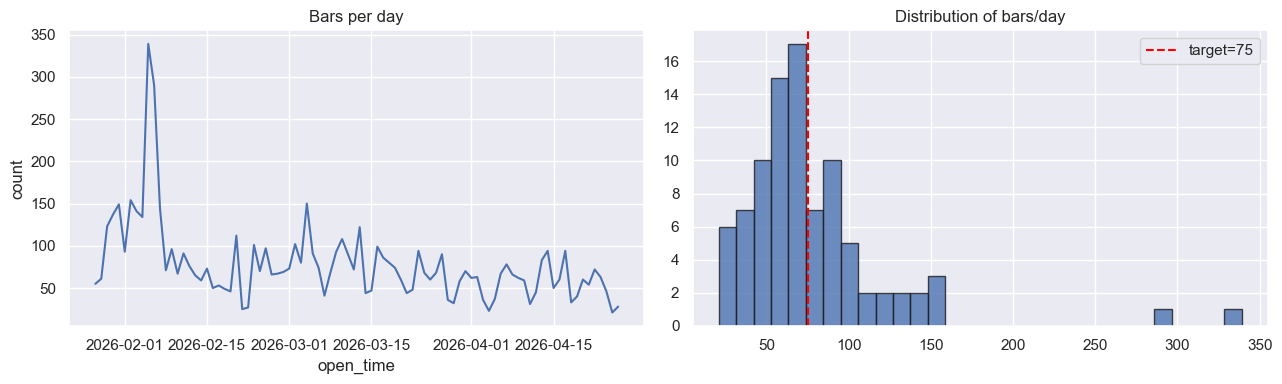

count     90.000000
mean      77.766667
std       47.333635
min       21.000000
25%       50.750000
50%       68.000000
75%       92.500000
max      339.000000


In [10]:
bars_per_day = df.groupby(df["open_time"].dt.date).size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bars_per_day.plot(ax=axes[0], title="Bars per day", ylabel="count")
axes[1].hist(bars_per_day, bins=30, edgecolor="k", alpha=0.8)
axes[1].axvline(TARGET_BARS_PER_DAY, color="red", linestyle="--", label=f"target={TARGET_BARS_PER_DAY}")
axes[1].set_title("Distribution of bars/day")
axes[1].legend()
plt.tight_layout()
plt.show()

print(bars_per_day.describe().to_string())

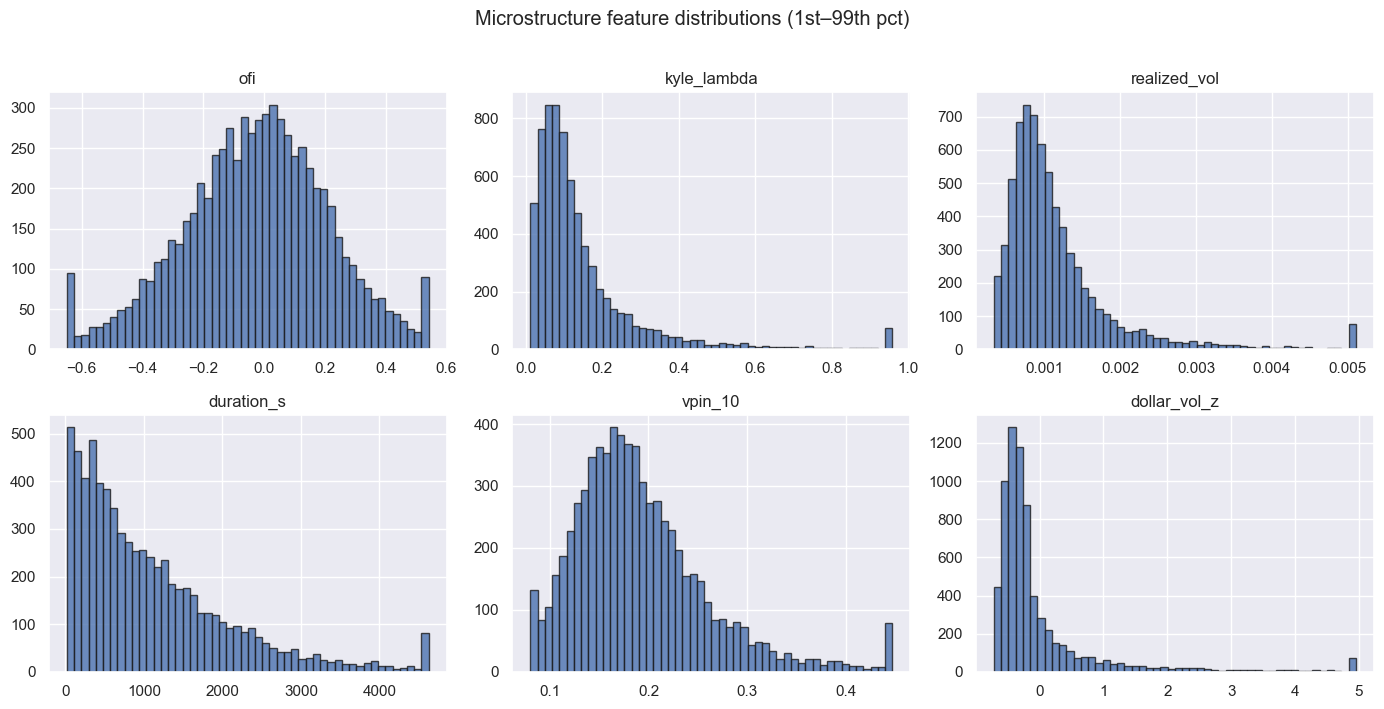

In [53]:
feat_cols = ["ofi", "kyle_lambda", "realized_vol", "duration_s", "vpin_10", "dollar_vol_z"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, feat_cols):
    data = df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    data.clip(lo, hi).hist(bins=50, ax=ax, edgecolor="k", alpha=0.8)
    ax.set_title(col)
plt.suptitle("Microstructure feature distributions (1st–99th pct)", y=1.01)
plt.tight_layout()
plt.show()

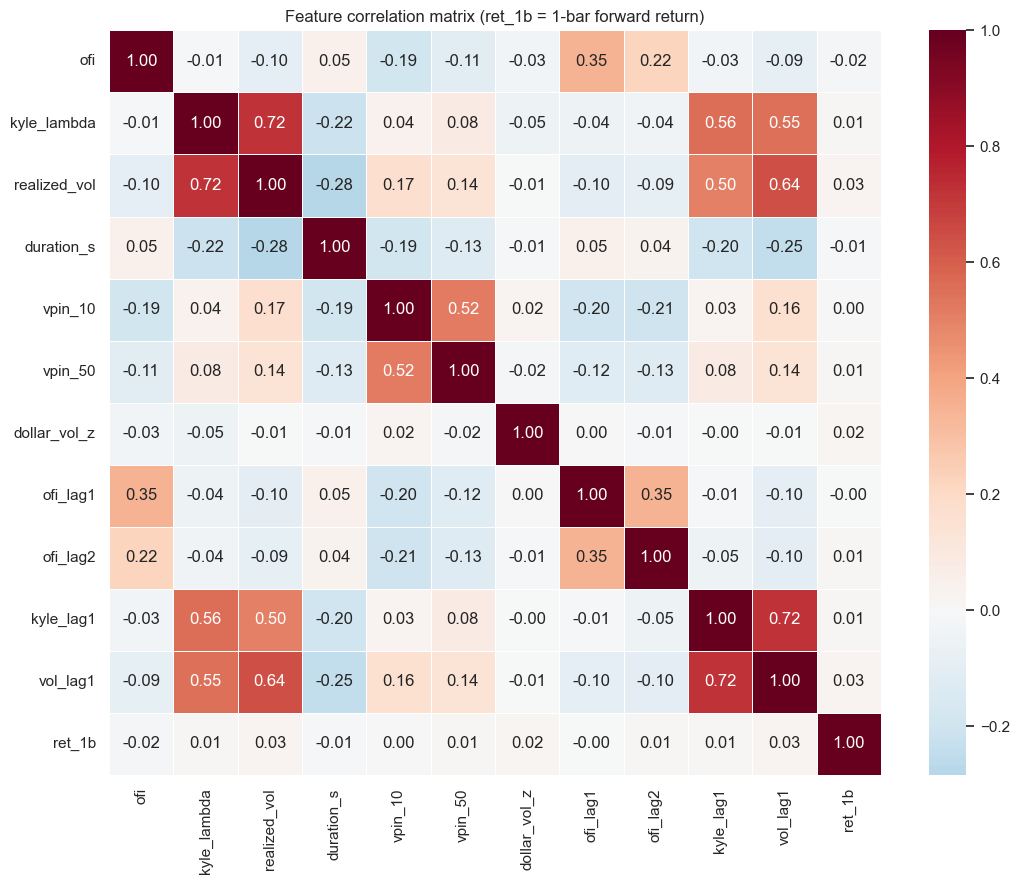

In [12]:
corr_cols = ["ofi", "kyle_lambda", "realized_vol", "duration_s",
             "vpin_10", "vpin_50", "dollar_vol_z",
             "ofi_lag1", "ofi_lag2", "kyle_lag1", "vol_lag1", "ret_1b"]

corr = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="RdBu_r", linewidths=0.4, ax=ax)
ax.set_title("Feature correlation matrix (ret_1b = 1-bar forward return)")
plt.tight_layout()
plt.show()

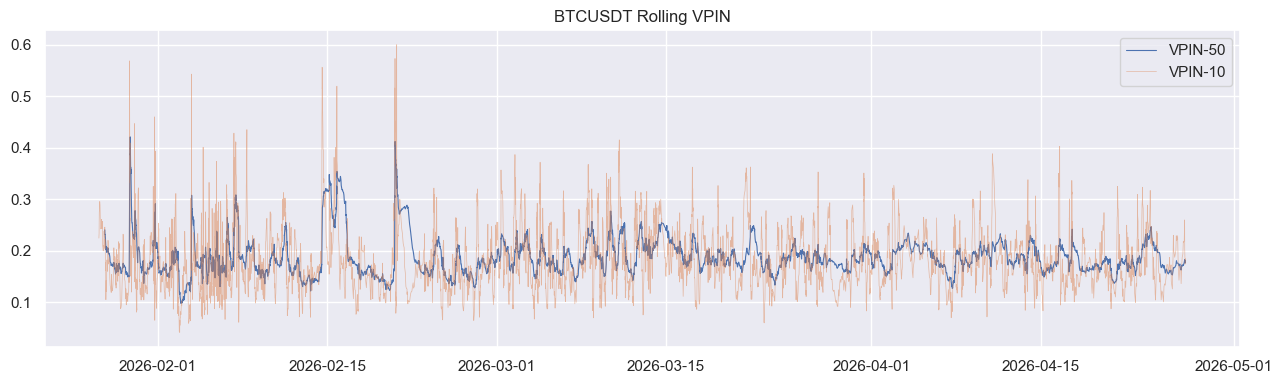

In [13]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["open_time"], df["vpin_50"], lw=0.8, label="VPIN-50")
ax.plot(df["open_time"], df["vpin_10"], lw=0.5, alpha=0.5, label="VPIN-10")
ax.set_title(f"{SYMBOL} Rolling VPIN")
ax.legend()
plt.tight_layout()
plt.show()

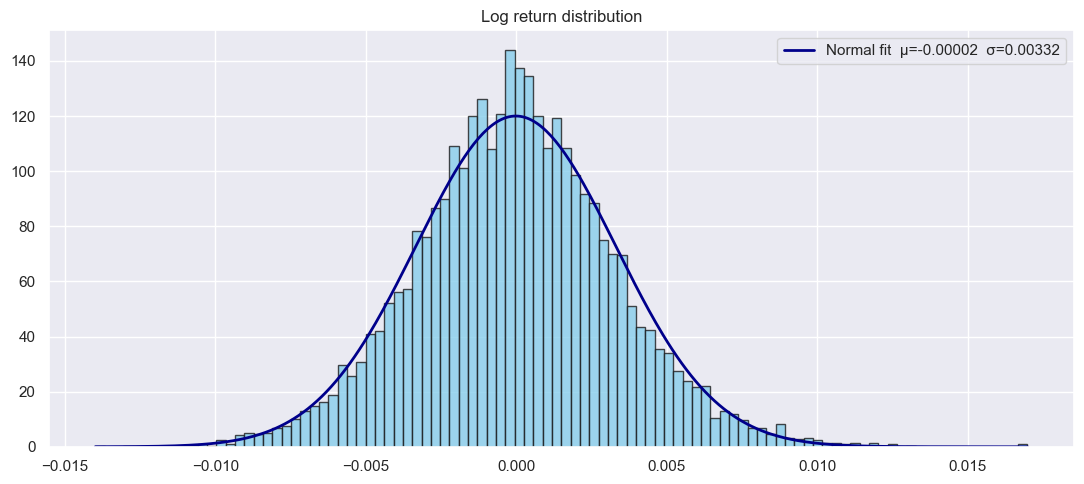

In [14]:
from scipy.stats import norm

data = df["log_return"].dropna()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(data, bins=100, color="skyblue", edgecolor="k", alpha=0.8, density=True)

mu, sigma = data.mean(), data.std()
x = np.linspace(data.min(), data.max(), 400)
ax.plot(x, norm.pdf(x, mu, sigma), color="darkblue", lw=2, label=f"Normal fit  μ={mu:.5f}  σ={sigma:.5f}")

ax.set_title("Log return distribution")
ax.legend()
plt.tight_layout()
plt.show()

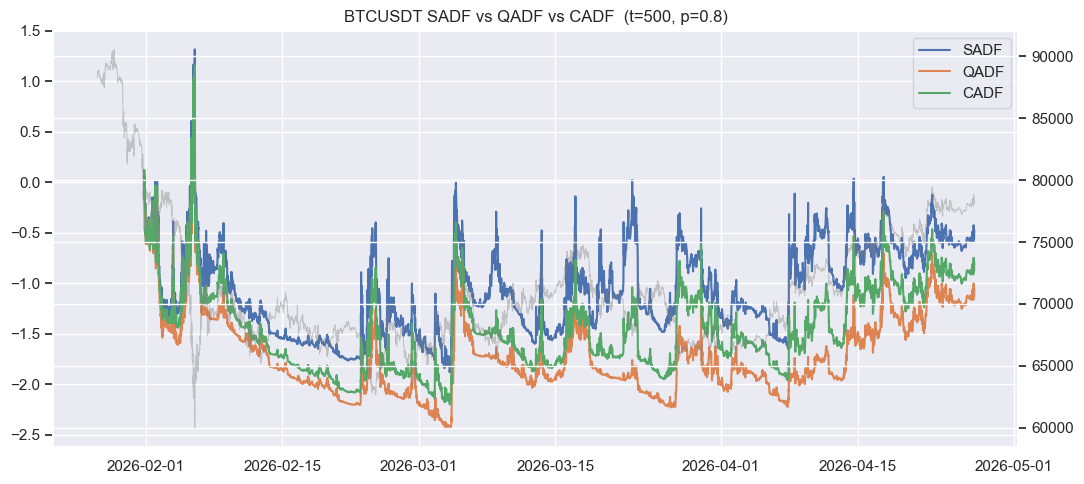

cadf  non-null : 6,498 / 6,999


In [58]:
qadf_mat = qadf(np.log(df['close']),
                t = 500,
                p = 0.8)

# col 3 = c = conditional mean  E[ADF | ADF ≥ Q(0.8)]
df['cadf'] = qadf_mat[:, 3]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df["open_time"], qadf_mat[:,0], label="SADF")
ax.plot(df["open_time"], qadf_mat[:,1], label="QADF")
ax.plot(df["open_time"], qadf_mat[:,3], label="CADF")
ax.set_title(f"{SYMBOL} SADF vs QADF vs CADF  (t=500, p=0.8)")
ax.legend()

ax2 = ax.twinx()
ax2.plot(df["open_time"], df["close"], color='grey', alpha=0.4, lw=0.7)
plt.tight_layout()
plt.show()

print(f"cadf  non-null : {df['cadf'].notna().sum():,} / {len(df):,}")

count    6994.000000
mean        0.003256
std         0.000657
min         0.001507
25%         0.002776
50%         0.003178
75%         0.003673
max         0.005867


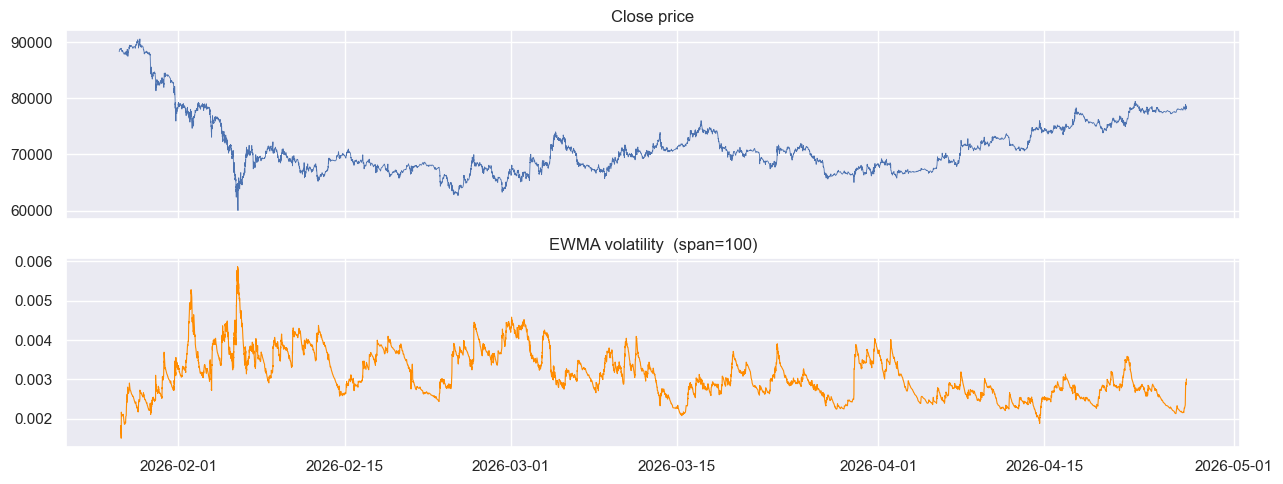

In [17]:
# ── 10. EWMA volatility estimator ────────────────────────────────────────────
EWMA_SPAN = 100    # ~20-bar exponential window

df['ewm_vol'] = df['log_return'].ewm(span=EWMA_SPAN, min_periods=5).std()

print(df['ewm_vol'].describe().to_string())

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(df['open_time'], df['close'], lw=0.6)
axes[0].set_title('Close price')
axes[1].plot(df['open_time'], df['ewm_vol'], lw=0.8, color='darkorange')
axes[1].set_title(f'EWMA volatility  (span={EWMA_SPAN})')
plt.tight_layout()
plt.show()

In [56]:
# ── 11. Triple barrier labeling ──────────────────────────────────────────────
BARRIER_MULT   = 2.0   # symmetric: width = BARRIER_MULT × ewm_vol on each side
VERTICAL_HOURS = 3     # maximum holding period


def triple_barrier_labels(df, barrier_mult=2.0, vertical_hours=6):
    """
    Labels each bar with the first barrier touched:
      +1  upper barrier  (close ≥ p0 × (1 + k·σ))
      -1  lower barrier  (close ≤ p0 × (1 - k·σ))
       0  vertical barrier expired; sign of return at expiry used, 0 if flat
    """
    open_times_ns = df['open_time'].astype('int64').values
    closes        = df['close'].values
    vols          = df['ewm_vol'].values
    vert_ns       = int(pd.Timedelta(hours=vertical_hours).value)

    n      = len(df)
    labels = np.zeros(n, dtype=np.int8)
    rets   = np.full(n, np.nan)

    for i in range(n - 1):
        vol = vols[i]
        if np.isnan(vol) or vol == 0:
            continue

        p0    = closes[i]
        upper = p0 * (1.0 + barrier_mult * vol)
        lower = p0 * (1.0 - barrier_mult * vol)

        j_end = int(np.searchsorted(open_times_ns, open_times_ns[i] + vert_ns, side='right')) - 1
        j_end = min(j_end, n - 1)

        for j in range(i + 1, j_end + 1):
            p = closes[j]
            if p >= upper:
                labels[i] = 1
                rets[i]   = np.log(p / p0)
                break
            elif p <= lower:
                labels[i] = -1
                rets[i]   = np.log(p / p0)
                break
        else:
            # vertical barrier: no touch — label by sign of return at expiry
            if j_end > i:
                r         = np.log(closes[j_end] / p0)
                rets[i]   = r
                labels[i] = int(np.sign(r))

    return labels, rets


labels, rets = triple_barrier_labels(df, BARRIER_MULT, VERTICAL_HOURS)
df['tb_label'] = labels
df['tb_ret']   = rets

counts = pd.Series(labels).value_counts().sort_index()
print(counts.rename({-1: 'short (-1)', 0: 'neutral (0)', 1: 'long (+1)'}).to_string())
print(f"\nLabeled: {(~np.isnan(rets)).sum():,} / {len(df):,} bars")

short (-1)     3476
neutral (0)       8
long (+1)      3515

Labeled: 6,993 / 6,999 bars


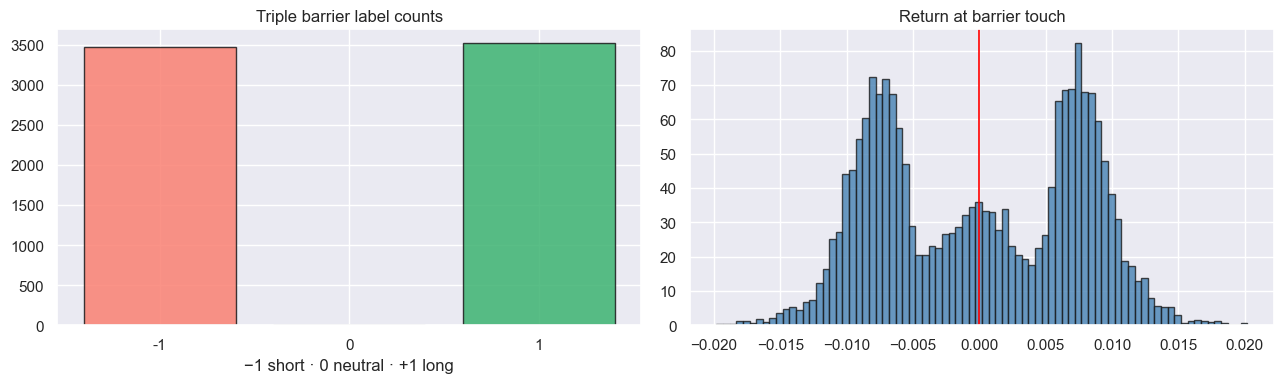

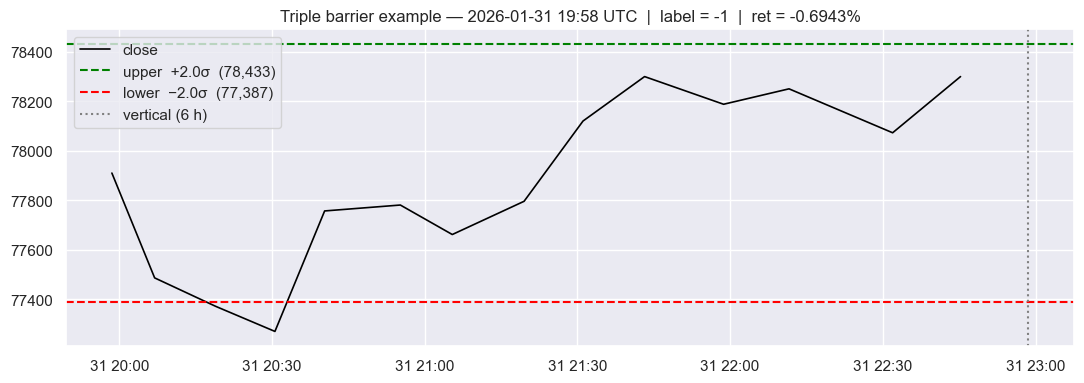

In [57]:
# ── 12. Triple barrier visualization ─────────────────────────────────────────

# --- Label distribution + return histogram ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['tb_label'].value_counts().sort_index()
colors = {-1: 'salmon', 0: 'lightgrey', 1: 'mediumseagreen'}
axes[0].bar([str(k) for k in counts.index], counts.values,
            color=[colors[k] for k in counts.index], edgecolor='k', alpha=0.85)
axes[0].set_title('Triple barrier label counts')
axes[0].set_xlabel('−1 short · 0 neutral · +1 long')

axes[1].hist(df['tb_ret'].dropna(), bins=80, edgecolor='k', alpha=0.8,
             color='steelblue', density=True)
axes[1].axvline(0, color='red', lw=1.2)
axes[1].set_title('Return at barrier touch')
plt.tight_layout()
plt.show()

# --- Single-event example: price path + barriers ---
ex_i  = df.loc[df['tb_label'] != 0].index[500]
p0    = df.loc[ex_i, 'close']
vol   = df.loc[ex_i, 'ewm_vol']
t0    = df.loc[ex_i, 'open_time']
t1    = t0 + pd.Timedelta(hours=VERTICAL_HOURS)
upper = p0 * (1 + BARRIER_MULT * vol)
lower = p0 * (1 - BARRIER_MULT * vol)

chunk = df.loc[(df['open_time'] >= t0) & (df['open_time'] <= t1)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(chunk['open_time'], chunk['close'], lw=1.2, color='black', label='close')
ax.axhline(upper, color='green', ls='--', lw=1.5, label=f'upper  +{BARRIER_MULT}σ  ({upper:,.0f})')
ax.axhline(lower, color='red',   ls='--', lw=1.5, label=f'lower  −{BARRIER_MULT}σ  ({lower:,.0f})')
ax.axvline(t1, color='grey', ls=':', lw=1.5, label='vertical (6 h)')
ax.set_title(
    f'Triple barrier example — {t0.strftime("%Y-%m-%d %H:%M")} UTC'
    f'  |  label = {df.loc[ex_i, "tb_label"]:+d}'
    f'  |  ret = {df.loc[ex_i, "tb_ret"]:.4%}'
)
ax.legend()
plt.tight_layout()
plt.show()

In [82]:
# ── 13. CUMSUM filter on CADF → event timestamps ─────────────────────────────

def cumsum_filter(series: pd.Series, h: float) -> pd.DatetimeIndex:
    """
    Symmetric CUMSUM filter (López de Prado, AFML §2.5).

    Tracks two running accumulators on first-differences of `series`:
      s_pos resets to 0 and fires an event when it reaches +h
      s_neg resets to 0 and fires an event when it reaches -h
    Returns the index values (timestamps) of all fired events.
    """
    events = []
    s_pos = s_neg = 0.0
    for t, v in series.diff().dropna().items():
        s_pos = max(0.0, s_pos + v)
        s_neg = min(0.0, s_neg + v)
        if s_pos >= h:
            s_pos = 0.0
            events.append(t)
        elif s_neg <= -h:
            s_neg = 0.0
            events.append(t)
    return pd.DatetimeIndex(events)


cadf_series = df.set_index('open_time')['cadf'].dropna()

# Threshold = mean absolute bar-to-bar change of CADF
h = float(cadf_series.diff().abs().mean())*4.2
print(f"CUMSUM threshold h  = {h:.4f}")

event_times = cumsum_filter(cadf_series, h=h)
print(f"Events detected     = {len(event_times):,}  /  {len(cadf_series):,} valid bars"
      f"  ({len(event_times) / len(cadf_series) * 100:.1f}%)")

CUMSUM threshold h  = 0.1193
Events detected     = 711  /  6,498 valid bars  (10.9%)


Sampled bars : 711
tb_label
short (-1)    346
long (+1)     365


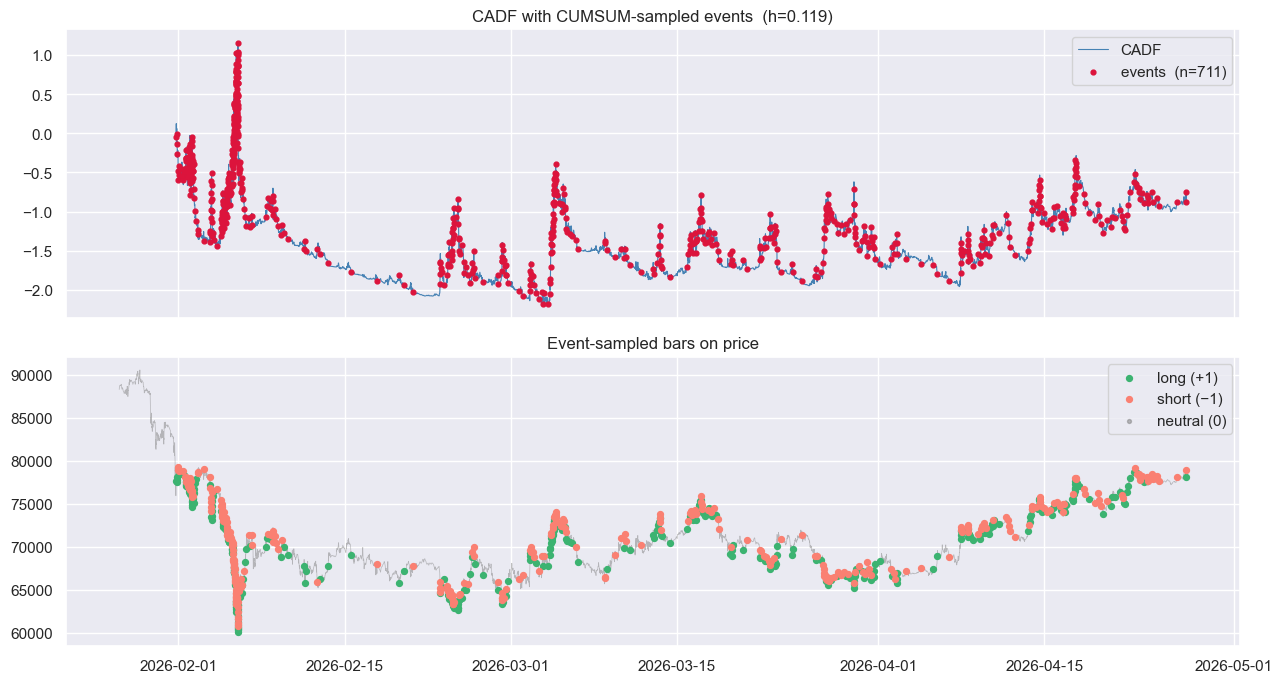

In [83]:
# ── 14. Event-sampled labeled dataset ────────────────────────────────────────

df_indexed = df.set_index('open_time')
df_sampled = df_indexed.loc[event_times].dropna(subset=['tb_label', 'ewm_vol']).copy()

print(f"Sampled bars : {len(df_sampled):,}")
counts = df_sampled['tb_label'].value_counts().sort_index()
print(counts.rename({-1: 'short (-1)', 0: 'neutral (0)', 1: 'long (+1)'}).to_string())

# --- Plot: events on CADF + color-coded labels on price ---
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(df['open_time'], df['cadf'], lw=0.8, color='steelblue', label='CADF')
axes[0].scatter(event_times,
                df_indexed.loc[event_times, 'cadf'],
                color='crimson', s=12, zorder=5, label=f'events  (n={len(event_times):,})')
axes[0].set_title(f'CADF with CUMSUM-sampled events  (h={h:.3f})')
axes[0].legend()

long_mask  = df_sampled['tb_label'] ==  1
short_mask = df_sampled['tb_label'] == -1
neut_mask  = df_sampled['tb_label'] ==  0

axes[1].plot(df['open_time'], df['close'], lw=0.5, color='grey', alpha=0.5)
axes[1].scatter(df_sampled.loc[long_mask].index,  df_sampled.loc[long_mask,  'close'],
                color='mediumseagreen', s=18, zorder=5, label='long (+1)')
axes[1].scatter(df_sampled.loc[short_mask].index, df_sampled.loc[short_mask, 'close'],
                color='salmon',        s=18, zorder=5, label='short (−1)')
axes[1].scatter(df_sampled.loc[neut_mask].index,  df_sampled.loc[neut_mask,  'close'],
                color='grey',          s=8,  zorder=4, alpha=0.5, label='neutral (0)')
axes[1].set_title('Event-sampled bars on price')
axes[1].legend()

plt.tight_layout()
plt.show()